In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../datasets/GlobalLandTemperaturesByCountry.csv")

In [3]:
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


# Global Land Temperatures Analysis

This notebook explores historical global land temperature data by country using Python data analysis and visualization tools.

The objective is to identify climate trends, temperature evolution over time, and geographic patterns through exploratory data analysis and time series visualization techniques.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  str    
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  str    
dtypes: float64(2), str(2)
memory usage: 17.6 MB


In [5]:
df["dt"] = pd.to_datetime(df["dt"])

In [6]:
df["year"] = df["dt"].dt.year

In [7]:
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year
0,1743-11-01,4.384,2.294,Åland,1743
1,1743-12-01,NaN,NaN,Åland,1743
2,1744-01-01,NaN,NaN,Åland,1744
3,1744-02-01,NaN,NaN,Åland,1744
4,1744-03-01,NaN,NaN,Åland,1744


In [8]:
yearly_temp = (
    df.groupby("year")["AverageTemperature"]
    .mean()
)

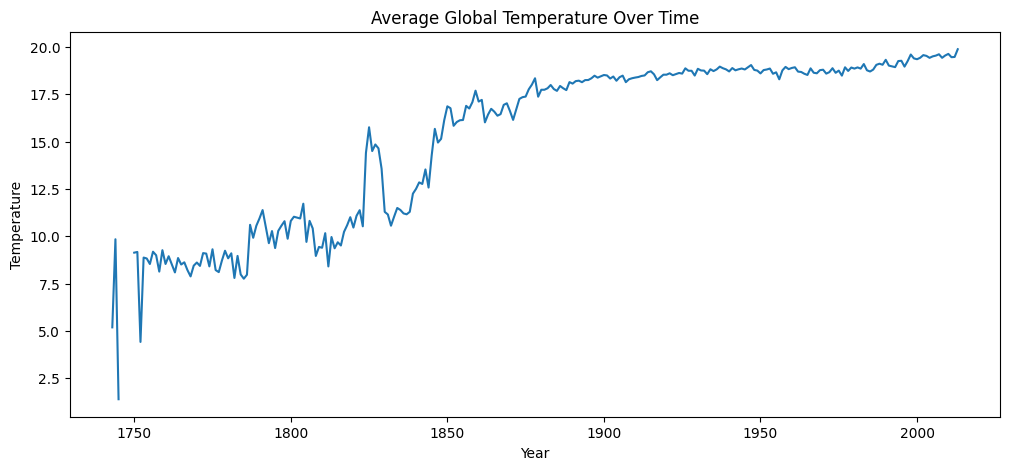

In [9]:
plt.figure(figsize=(12,5))

plt.plot(yearly_temp.index, yearly_temp.values)

plt.title("Average Global Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature")

plt.show()

# Global Temperature Trend Analysis

The time series visualization shows a clear long-term increase in average global temperatures over time.

Key observations:

- Early historical records show higher variability and instability
- Temperatures begin to rise more consistently after the mid-19th century
- The upward trend becomes more evident during the 20th century
- Recent decades display the highest average temperatures in the dataset

This visualization suggests a long-term warming trend in global land temperatures.

# Rolling Average Analysis

A rolling average helps smooth short-term fluctuations and highlights long-term trends in the data.

This technique is commonly used in time series analysis to better visualize climate tendencies over extended periods.

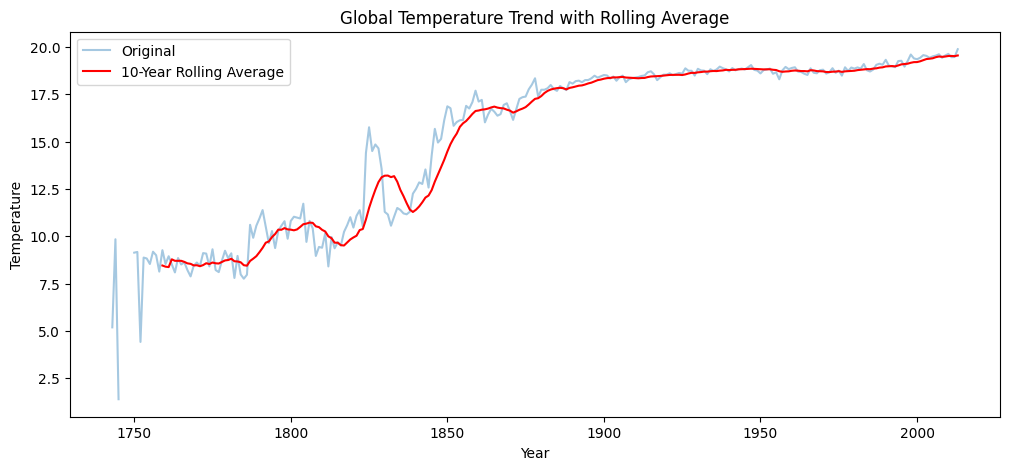

In [10]:
rolling_temp = yearly_temp.rolling(window=10).mean()

plt.figure(figsize=(12,5))

plt.plot(yearly_temp.index, yearly_temp.values, alpha=0.4, label="Original")
plt.plot(rolling_temp.index, rolling_temp.values, color="red", label="10-Year Rolling Average")

plt.title("Global Temperature Trend with Rolling Average")
plt.xlabel("Year")
plt.ylabel("Temperature")

plt.legend()

plt.show()

# Hottest Countries Analysis

The next step is to identify which countries present the highest average land temperatures in the dataset.

This analysis helps compare geographic temperature patterns and identify warmer regions around the world.

In [11]:
top_countries = (
    df.groupby("Country")["AverageTemperature"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

Country
Djibouti                28.816603
Mali                    28.441977
Burkina Faso            28.083507
Senegal                 27.967375
Aruba                   27.920390
United Arab Emirates    27.693995
Mauritania              27.620256
Gambia                  27.538552
Niger                   27.458973
Curaçao                 27.353415
Name: AverageTemperature, dtype: float64

# Top 10 Hottest Countries

The following visualization displays the countries with the highest average temperatures recorded in the dataset.

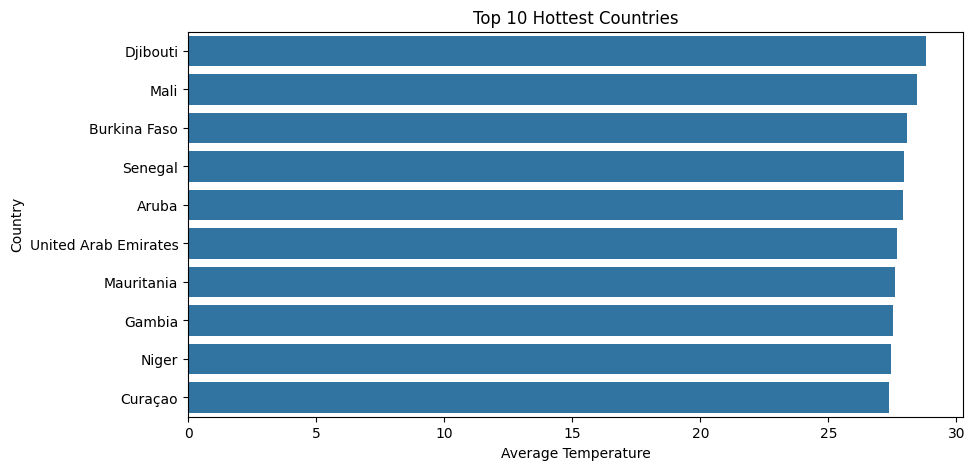

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Hottest Countries")
plt.xlabel("Average Temperature")
plt.ylabel("Country")

plt.show()

# Interpretation of Geographic Temperature Patterns

The visualization reveals that several tropical and desert-region countries dominate the ranking of highest average temperatures.

Key observations:

- Countries closer to the equator tend to present higher temperatures
- Climate conditions strongly influence long-term averages
- Geographic location plays a major role in temperature distribution

This analysis highlights how climate patterns vary globally across different regions.

# Temperature Evolution in Spain

This section analyzes the evolution of average land temperature in Spain over time.

The goal is to observe long-term temperature trends for a specific country and compare them with the global pattern previously analyzed.

In [13]:
spain_temp = (
    df[df["Country"] == "Spain"]
    .groupby("year")["AverageTemperature"]
    .mean()
)

spain_temp.head()

year
1743     9.346000
1744    14.537375
1745     7.931750
1746          NaN
1747          NaN
Name: AverageTemperature, dtype: float64

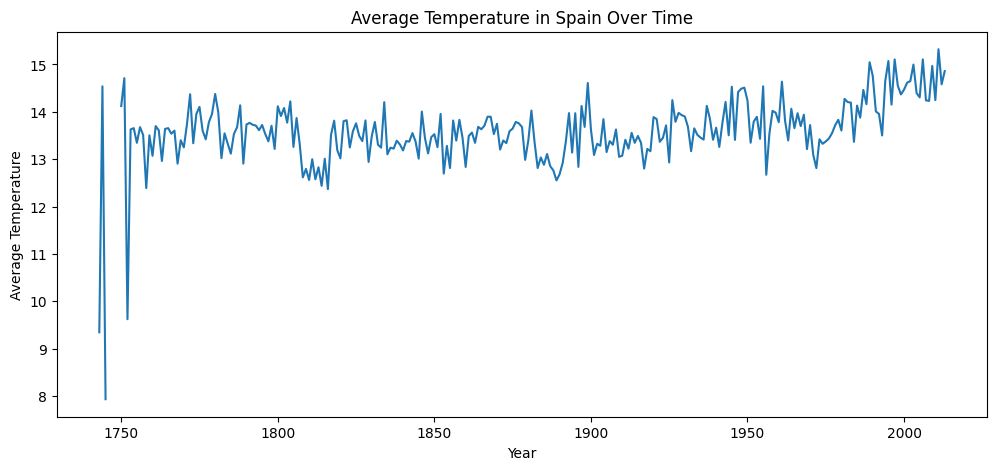

In [14]:
plt.figure(figsize=(12,5))

plt.plot(spain_temp.index, spain_temp.values)

plt.title("Average Temperature in Spain Over Time")
plt.xlabel("Year")
plt.ylabel("Average Temperature")

plt.show()

# Spain Temperature Trend Interpretation

The time series shows how average land temperatures in Spain have evolved over time.

Key points to observe:

- Long-term temperature changes
- Periods of higher variability
- Recent warming patterns
- Differences between historical and modern records

This type of country-specific analysis helps identify local climate trends within the global temperature dataset.

# Comparing Temperature Trends Across Countries

This section compares the long-term temperature evolution of several countries:

- Spain
- United States
- India
- China

The objective is to identify similarities and differences in climate trends across different regions of the world.

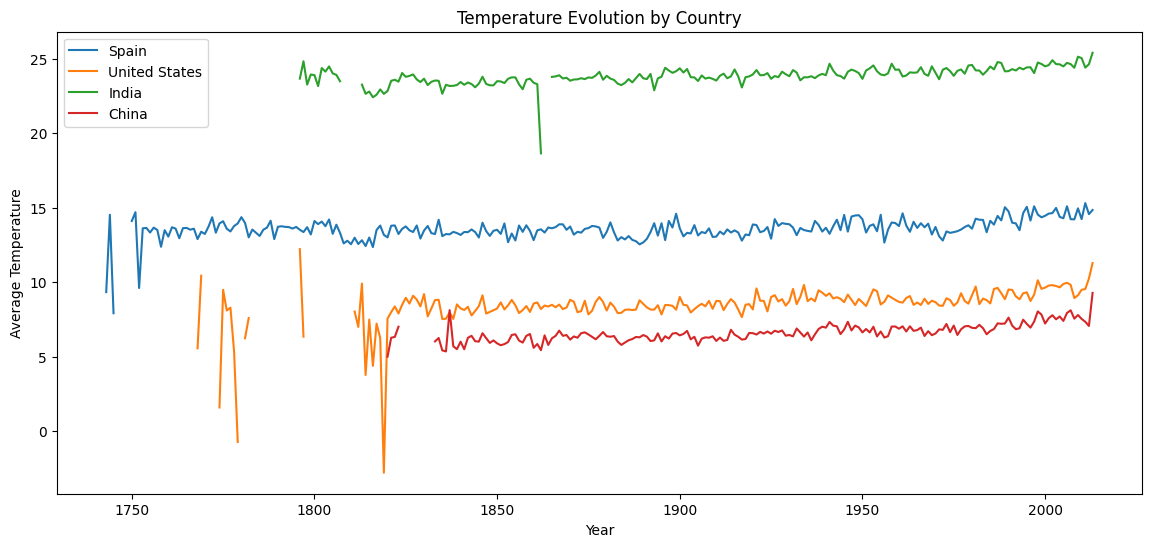

In [15]:
countries = ["Spain", "United States", "India", "China"]

plt.figure(figsize=(14,6))

for country in countries:
    
    country_temp = (
        df[df["Country"] == country]
        .groupby("year")["AverageTemperature"]
        .mean()
    )
    
    plt.plot(
        country_temp.index,
        country_temp.values,
        label=country
    )

plt.title("Temperature Evolution by Country")
plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.legend()

plt.show()

# Comparative Analysis

The comparison reveals distinct climate behaviors across countries.

Key observations:

- India generally presents the highest average temperatures
- Spain shows moderate temperatures with visible warming trends
- United States displays greater variability over time
- China also presents a progressive temperature increase in recent decades

Despite regional differences, most countries show an upward temperature trend in modern years, suggesting a broader global warming pattern.

In [16]:
early_period = df[(df["year"] >= 1900) & (df["year"] <= 1920)]
recent_period = df[(df["year"] >= 1990) & (df["year"] <= 2010)]

early_avg = early_period.groupby("Country")["AverageTemperature"].mean()
recent_avg = recent_period.groupby("Country")["AverageTemperature"].mean()

temperature_change = (recent_avg - early_avg).dropna().sort_values(ascending=False)

temperature_change.head(10)

Country
Mongolia                  1.825278
Kazakhstan                1.625734
Svalbard And Jan Mayen    1.560476
Turkmenistan              1.551837
Russia                    1.546710
Greenland                 1.542341
Denmark                   1.533683
Uzbekistan                1.504230
Canada                    1.481111
North Korea               1.437163
Name: AverageTemperature, dtype: float64

# Countries with the Highest Temperature Increase

The following chart shows the countries with the largest increase in average temperature between the early 20th century and recent decades.

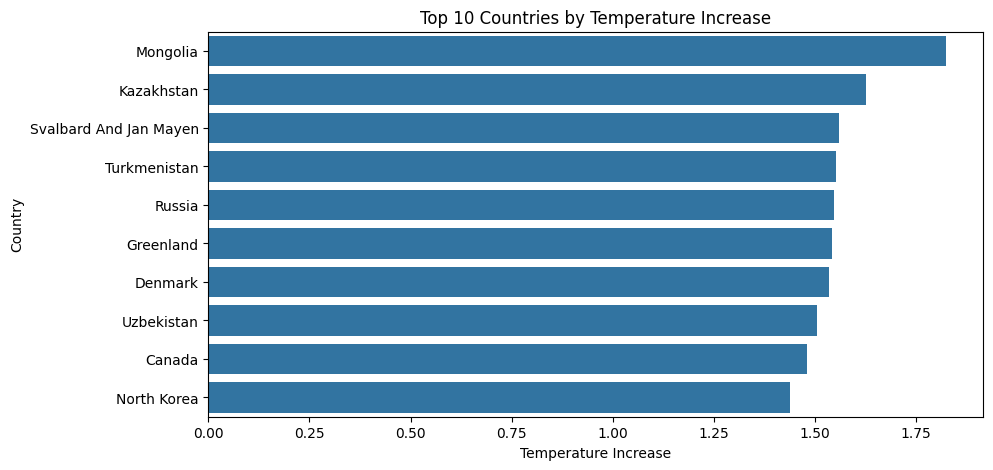

In [17]:
top_warming_countries = temperature_change.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_warming_countries.values,
    y=top_warming_countries.index
)

plt.title("Top 10 Countries by Temperature Increase")
plt.xlabel("Temperature Increase")
plt.ylabel("Country")

plt.show()

# Interpretation

This ranking highlights the countries that experienced the largest estimated increase in average land temperature between the selected historical and recent periods.

This comparison provides a more analytical perspective than simply looking at absolute temperatures, because it focuses on temperature change over time.

# Temperature Heatmap by Decade

This visualization compares average temperatures across countries and decades using a heatmap.

Heatmaps are useful for identifying long-term climate patterns, regional differences, and gradual warming trends through color intensity.

In [18]:
df["decade"] = (df["year"] // 10) * 10

heatmap_data = (
    df.groupby(["Country", "decade"])["AverageTemperature"]
    .mean()
    .unstack()
)

heatmap_data.head()

decade,1740,1750,1760,1770,1780,1790,1800,1810,1820,1830,...,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.379571,...,13.706792,13.691550,14.386883,14.000892,13.961283,14.035983,14.595183,14.732458,15.365650,15.504727
Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.027567,24.155042,24.250850,24.099275,24.155550,24.151075,24.428567,24.626283,24.891983,25.033841
Albania,11.036,12.362908,12.386633,12.802883,12.516992,12.769667,12.652933,12.032733,12.452017,12.054758,...,12.822600,12.897350,12.667342,12.999192,12.919900,12.610950,12.775675,13.149892,13.529558,13.904409
Algeria,NaN,NaN,NaN,NaN,23.162950,22.973353,22.996563,22.060167,22.732183,22.544067,...,22.995742,23.200767,23.259642,23.092575,23.232308,22.929833,23.515033,23.651742,24.192267,24.562455
American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,26.399842,26.734708,26.766642,26.773925,26.650492,26.756117,26.911825,27.103125,27.246783,27.275227


In [19]:
selected_countries = [
    "Spain",
    "United States",
    "India",
    "China",
    "Russia",
    "Brazil",
    "Canada"
]

filtered_heatmap = heatmap_data.loc[selected_countries]

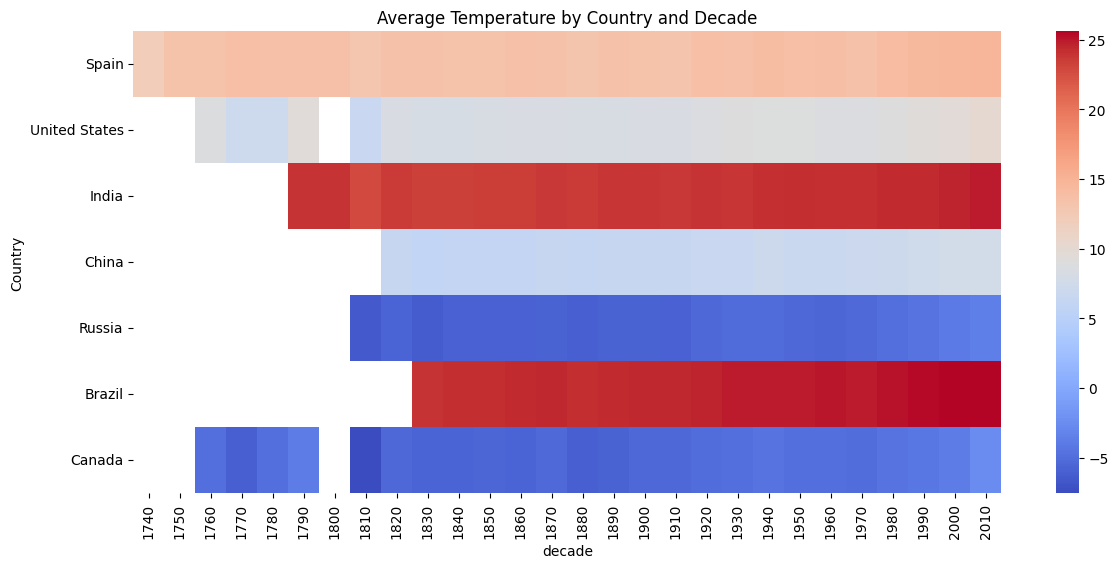

In [20]:
plt.figure(figsize=(14,6))

sns.heatmap(
    filtered_heatmap,
    cmap="coolwarm"
)

plt.title("Average Temperature by Country and Decade")

plt.show()

# Heatmap Interpretation

The heatmap allows us to visually compare temperature evolution across multiple countries and decades.

Key observations:

- Warmer colors indicate higher average temperatures
- Cooler colors represent lower temperatures
- Several countries show progressively warmer patterns in recent decades
- Climate differences between geographic regions become visually apparent

This type of visualization is especially useful for identifying long-term trends and comparing multiple time series simultaneously.

# Recent Average Temperatures by Country

This section focuses on recent decades to identify countries with the highest average land temperatures.

Instead of analyzing the full historical period, we filter the dataset from 1990 onwards to better represent modern climate conditions.

In [21]:
recent_data = df[df["year"] >= 1990]

recent_country_temp = (
    recent_data.groupby("Country")["AverageTemperature"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

recent_country_temp

Country
Djibouti                29.540194
Mali                    29.184032
United Arab Emirates    28.767581
Burkina Faso            28.763606
Senegal                 28.723849
Aruba                   28.610859
Mauritania              28.458912
Gambia                  28.287637
Niger                   28.198028
Curaçao                 28.044482
Name: AverageTemperature, dtype: float64

# Top 10 Hottest Countries in Recent Decades

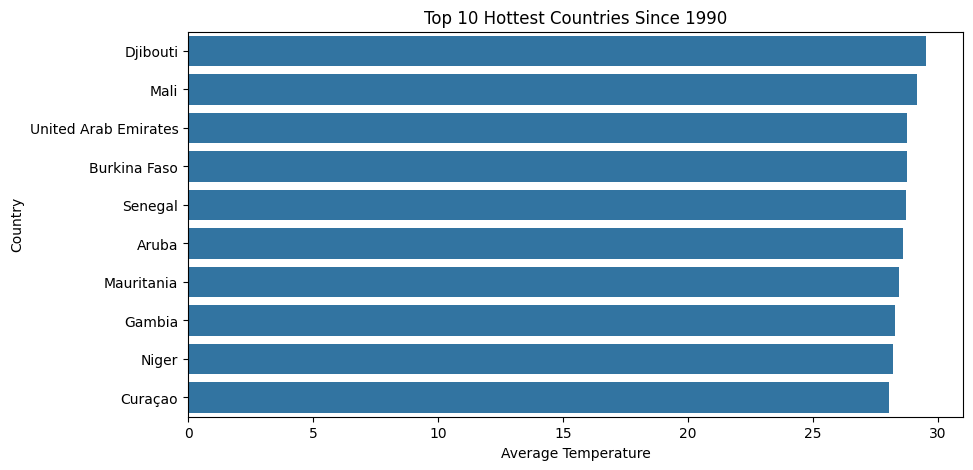

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=recent_country_temp.values,
    y=recent_country_temp.index
)

plt.title("Top 10 Hottest Countries Since 1990")
plt.xlabel("Average Temperature")
plt.ylabel("Country")

plt.show()

# Final Conclusions

This project explored historical global temperature data through exploratory data analysis and multiple visualization techniques.

Main insights obtained from the analysis:

- Global average temperatures show a clear long-term upward trend
- Several countries present significant warming patterns in recent decades
- Cold-region countries such as Mongolia, Russia, and Canada exhibit some of the strongest temperature increases
- Climate behavior varies across geographic regions, but many countries display progressive warming over time
- Heatmaps and comparative visualizations help reveal long-term climate patterns more effectively than raw numerical tables

Techniques applied during this analysis:

- Data cleaning
- Missing values analysis
- Time series analysis
- Country comparison
- Statistical aggregation
- Correlation exploration
- Heatmaps and advanced visualizations

This notebook demonstrates how Python visualization libraries can be used to transform large climate datasets into meaningful insights and visual storytelling.